<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/10_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clustering Techniques**

This notebook covers Clustering Techniques:

1. Introduction to Clustering
2. K-Means Clustering
3. Hierarchical Clustering
4. Density-Based Clustering with DBSCAN
5. Cluster Evaluation Metrics
6. Choosing the Right Clustering Algorithm
7. Advanced Clustering Techniques (Spectral & GMM)

# **1. Introduction to Clustering**

Clustering is a **unsupervised learning** technique — the training data has no labels or target values. Instead, the algorithm discovers **intrinsic structure** by grouping similar data points together.

## **1.1 Real-World Applications**

- **Market segmentation:** group customers by purchasing behavior without predefined categories
- **Anomaly detection:** identify points that don't belong to any natural cluster
- **Document organization:** group articles by topic without hand-labeling
- **Image compression:** cluster pixel colors to reduce the color palette

## **1.2 Three Fundamental Paradigms**

| Paradigm | Mechanism | Representative Algorithm |
|---|---|---|
| **Centroid-based** | Clusters defined by a central point | K-Means |
| **Connectivity-based** | Clusters built by hierarchical merging/splitting | Agglomerative |
| **Density-based** | Clusters defined by dense regions; noise identified explicitly | DBSCAN |

## **1.3 Unsupervised Learning as an Art**

Unlike supervised learning with clear accuracy metrics, clustering lacks ground truth labels for validation. The quality of a clustering solution depends on:
- Choice of algorithm and hyperparameters
- Feature scaling and preprocessing
- The inherent structure (or lack thereof) in the data

Dataset shape: (300, 2)


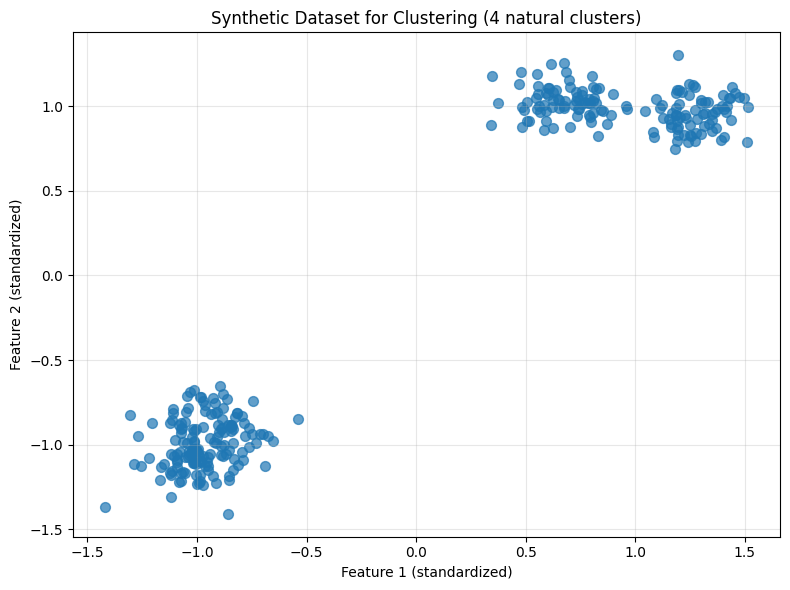

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Generate synthetic "blob" data: 300 points, 4 natural clusters
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)
X = StandardScaler().fit_transform(X)

print(f"Dataset shape: {X.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7)
plt.title("Synthetic Dataset for Clustering (4 natural clusters)")
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **2. K-Means Clustering**

K-Means is the most widely used clustering algorithm. It partitions data into **k predefined clusters** by iteratively refining cluster centroids.

## **2.1 The K-Means Algorithm**

1. **Initialize** $k$ centroids randomly (or via K-Means++ for better initialization)
2. **Assignment step:** assign each point to its nearest centroid (Euclidean distance)
3. **Update step:** recompute each centroid as the mean of all assigned points
4. Repeat steps 2–3 until convergence (assignments stop changing)

$$\text{Minimize: } \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

## **2.2 Strengths and Limitations**

| Strength | Limitation |
|---|---|
| Fast and scalable | Requires $k$ to be specified upfront |
| Works well with convex, isotropic clusters | Sensitive to initialization |
| Easily interpretable centroids | Struggles with non-spherical clusters |
| | Assigns all points to a cluster — no noise concept |

## **2.3 Choosing k: The Elbow Method**

Plot the **inertia** (sum of squared distances to nearest centroid) for different values of $k$. The optimal $k$ is at the "elbow" — the point where additional clusters yield diminishing reduction in inertia.

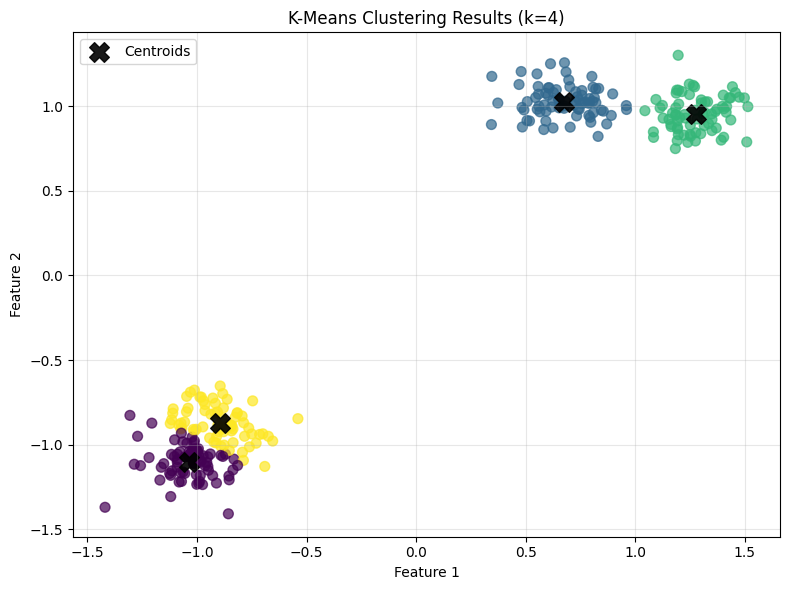

Inertia (k=4): 7.29


In [2]:
from sklearn.cluster import KMeans

# K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=2024, n_init=10)
y_kmeans = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.9, marker='X', label='Centroids')
plt.title("K-Means Clustering Results (k=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Inertia (k=4): {kmeans.inertia_:.2f}")


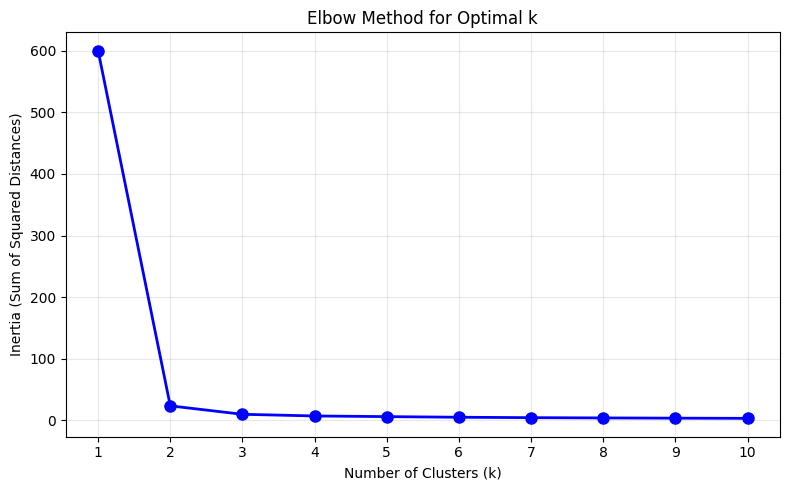

Inertia values by k:
  k= 1: 600.00
  k= 2: 23.68
  k= 3: 9.99
  k= 4: 7.29
  k= 5: 6.20
  k= 6: 5.21
  k= 7: 4.53
  k= 8: 4.10
  k= 9: 3.72
  k=10: 3.42


In [3]:
# Elbow method: find optimal k
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=2024, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Inertia values by k:")
for k, i in zip(k_range, inertia):
    print(f"  k={k:2d}: {i:.2f}")


# **3. Hierarchical Clustering**

Hierarchical clustering builds a **tree of nested clusters** (a dendrogram) by successively merging or splitting data points. Unlike K-Means, it does not require the number of clusters to be specified upfront.

## **3.1 Agglomerative (Bottom-Up) Approach**

scikit-learn implements the more common **agglomerative** variant:

1. Start: each data point is its own cluster
2. Merge the two closest clusters into one
3. Repeat until a single cluster remains or a stopping criterion is met

## **3.2 Linkage Criteria**

The linkage criterion defines how "distance" between clusters is measured:

| Method | Distance Definition | Effect |
|---|---|---|
| **Ward** | Minimizes within-cluster variance | Most compact clusters (default) |
| **Complete** | Maximum distance between points | Conservative merging |
| **Average** | Mean distance across all point pairs | Balanced |
| **Single** | Minimum distance between points | Chains long clusters |

## **3.3 Reading the Dendrogram**

The y-axis of a dendrogram represents the distance at which clusters were merged. To choose the number of clusters, draw a horizontal line at a desired height — the number of vertical lines it intersects equals the number of clusters.

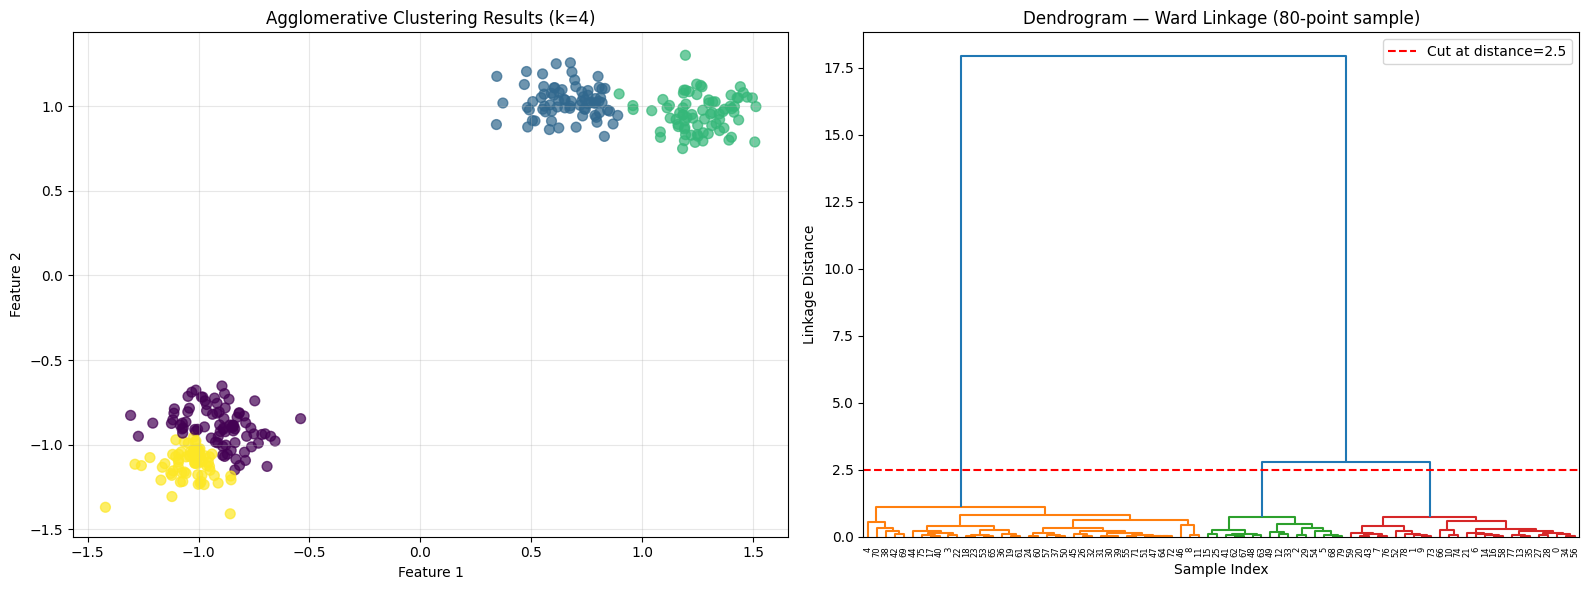

In [4]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative clustering with k=4
agg = AgglomerativeClustering(n_clusters=4)
y_agg = agg.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(X[:, 0], X[:, 1], c=y_agg, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title("Agglomerative Clustering Results (k=4)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True, alpha=0.3)

# Dendrogram (subsample for readability)
np.random.seed(42)
sample_idx = np.random.choice(len(X), 80, replace=False)
linked = linkage(X[sample_idx], method='ward')
dendrogram(linked, ax=axes[1], leaf_rotation=90, leaf_font_size=6, color_threshold=2.5)
axes[1].set_title("Dendrogram — Ward Linkage (80-point sample)")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Linkage Distance")
axes[1].axhline(y=2.5, color='red', linestyle='--', linewidth=1.5, label='Cut at distance=2.5')
axes[1].legend()

plt.tight_layout()
plt.show()


# **4. Density-Based Clustering with DBSCAN**

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** takes a fundamentally different approach: rather than defining clusters by centroids or hierarchical merging, it defines them by **dense regions** in feature space.

## **4.1 Core Concepts**

| Concept | Definition |
|---|---|
| **Core point** | Has ≥ `min_samples` within `eps` radius |
| **Border point** | Within `eps` of a core point, but has < `min_samples` neighbors |
| **Noise point** | Neither core nor border — labeled as outlier (−1) |

## **4.2 Key Hyperparameters**

- **`eps`**: Radius of the neighborhood around each point. Too small → too many noise points. Too large → all points merge into one cluster.  
- **`min_samples`**: Minimum density threshold to be considered a core point.

## **4.3 DBSCAN vs. K-Means**

| Feature | K-Means | DBSCAN |
|---|---|---|
| Cluster shape | Convex only | Arbitrary |
| Number of clusters | Must specify | Discovered automatically |
| Noise handling | No — all points assigned | Yes — noise labeled as −1 |
| Parameter sensitivity | k | eps, min_samples |

## **4.4 Choosing eps: k-Distance Plot**

Plot the distance to the $k$-th nearest neighbor for each point (sorted). The "elbow" in this curve suggests a good value for `eps`.

Clusters found : 2
Noise points   : 4 (1.3%)


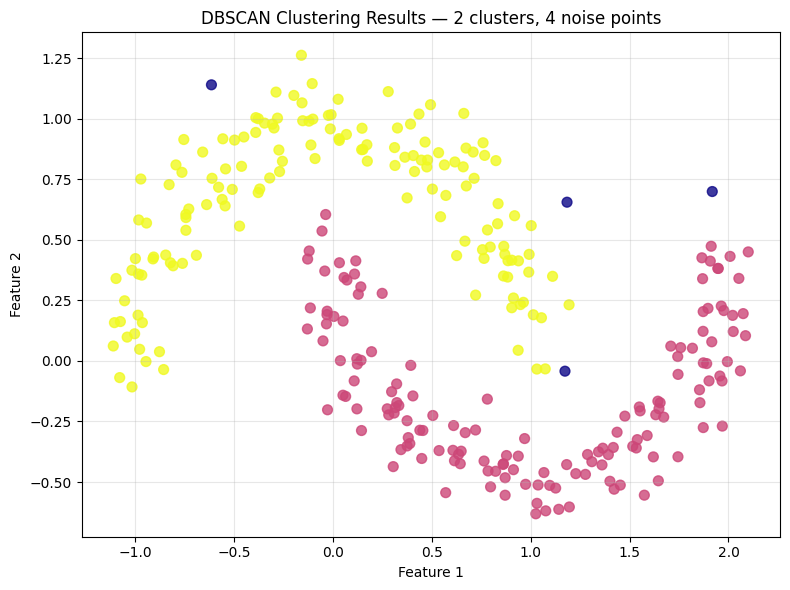

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Non-spherical "moon" dataset — K-Means would fail here
X_moon, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)

dbscan = DBSCAN(eps=0.2, min_samples=5)
y_db = dbscan.fit_predict(X_moon)

n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise    = list(y_db).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} ({n_noise/len(y_db)*100:.1f}%)")

plt.figure(figsize=(8, 6))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_db, cmap='plasma', s=50, alpha=0.8)
plt.title(f"DBSCAN Clustering Results — {n_clusters} clusters, {n_noise} noise points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


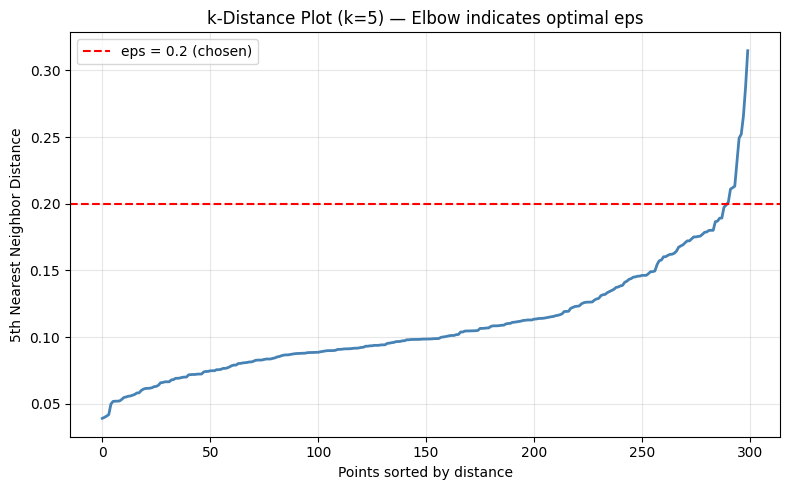

In [6]:
# k-Distance plot to guide eps selection
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_moon)
distances, _ = neighbors.kneighbors(X_moon)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances, linewidth=2, color='steelblue')
plt.axhline(y=0.2, color='red', linestyle='--', label='eps = 0.2 (chosen)')
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("k-Distance Plot (k=5) — Elbow indicates optimal eps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **5. Cluster Evaluation Metrics**

Without ground truth labels, evaluating clustering quality requires **internal metrics** that assess the structure of the clusters themselves.

## **5.1 Silhouette Score**

Measures how well each point fits within its own cluster vs. neighboring clusters:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where $a(i)$ = mean intra-cluster distance and $b(i)$ = mean nearest-cluster distance.

- Range: −1 (misclassified) to 1 (well-clustered)
- Closer to 1 → better-defined, well-separated clusters

## **5.2 Davies-Bouldin Index**

Evaluates the average similarity between each cluster and its most similar neighbor. **Lower is better.**

## **5.3 Adjusted Rand Index (ARI)**

An **external** metric — requires ground truth labels. Measures agreement between predicted and true cluster assignments, corrected for chance.

- Range: −1 to 1, where 1 = perfect agreement
- Only available when true labels are known

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Evaluation on known-cluster blob data
X_eval, y_true_eval = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)
kmeans_eval = KMeans(n_clusters=4, random_state=2024, n_init=10)
y_pred_eval = kmeans_eval.fit_predict(X_eval)

sil = silhouette_score(X_eval, y_pred_eval)
db  = davies_bouldin_score(X_eval, y_pred_eval)
ari = adjusted_rand_score(y_true_eval, y_pred_eval)

print(f"Silhouette Score     : {sil:.4f}  (range: -1 to 1, higher is better)")
print(f"Davies-Bouldin Index : {db:.4f}  (lower is better)")
print(f"Adjusted Rand Index  : {ari:.4f}  (1.0 = perfect agreement with truth)")

# Compare metrics across different k values
metrics_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=2024, n_init=10)
    y_k = km.fit_predict(X_eval)
    metrics_k.append({
        'k': k,
        'Silhouette': silhouette_score(X_eval, y_k),
        'Davies-Bouldin': davies_bouldin_score(X_eval, y_k),
        'ARI': adjusted_rand_score(y_true_eval, y_k)
    })

pd.DataFrame(metrics_k).set_index('k').round(4)


Silhouette Score     : 0.5343  (range: -1 to 1, higher is better)
Davies-Bouldin Index : 0.7017  (lower is better)
Adjusted Rand Index  : 0.8138  (1.0 = perfect agreement with truth)


,Silhouette,Davies-Bouldin,ARI
k,,,
2,0.8869,0.1686,0.4975
3,0.7683,0.3897,0.6971
4,0.5343,0.7017,0.8138
5,0.5203,0.7540,0.7611
6,0.4503,0.8749,0.6634
7,0.3892,0.9833,0.5558
8,0.3793,0.9020,0.5094


# **6. Choosing the Right Clustering Algorithm**

No single clustering algorithm performs best on all data types. Selection should be guided by the **shape, density, scale, and noise characteristics** of the dataset.

## **6.1 Decision Guide**

| Data Characteristic | Recommended Algorithm |
|---|---|
| Convex, isotropic clusters | **K-Means** |
| Non-convex, irregular shapes | **DBSCAN**, Spectral Clustering |
| Presence of noise / outliers | **DBSCAN** |
| Small datasets, dendrogram needed | **Hierarchical** |
| Large datasets | **K-Means**, MiniBatchKMeans |
| Probabilistic cluster membership | **Gaussian Mixture Models** |
| High-dimensional data | Reduce with PCA first, then any algorithm |

## **6.2 Visual Intuition**

Three canonical data shapes reveal algorithm strengths:
- **Gaussian blobs:** K-Means excels
- **Crescent moons:** DBSCAN handles non-convex shapes; K-Means fails
- **Concentric circles:** Only density/graph-based methods succeed

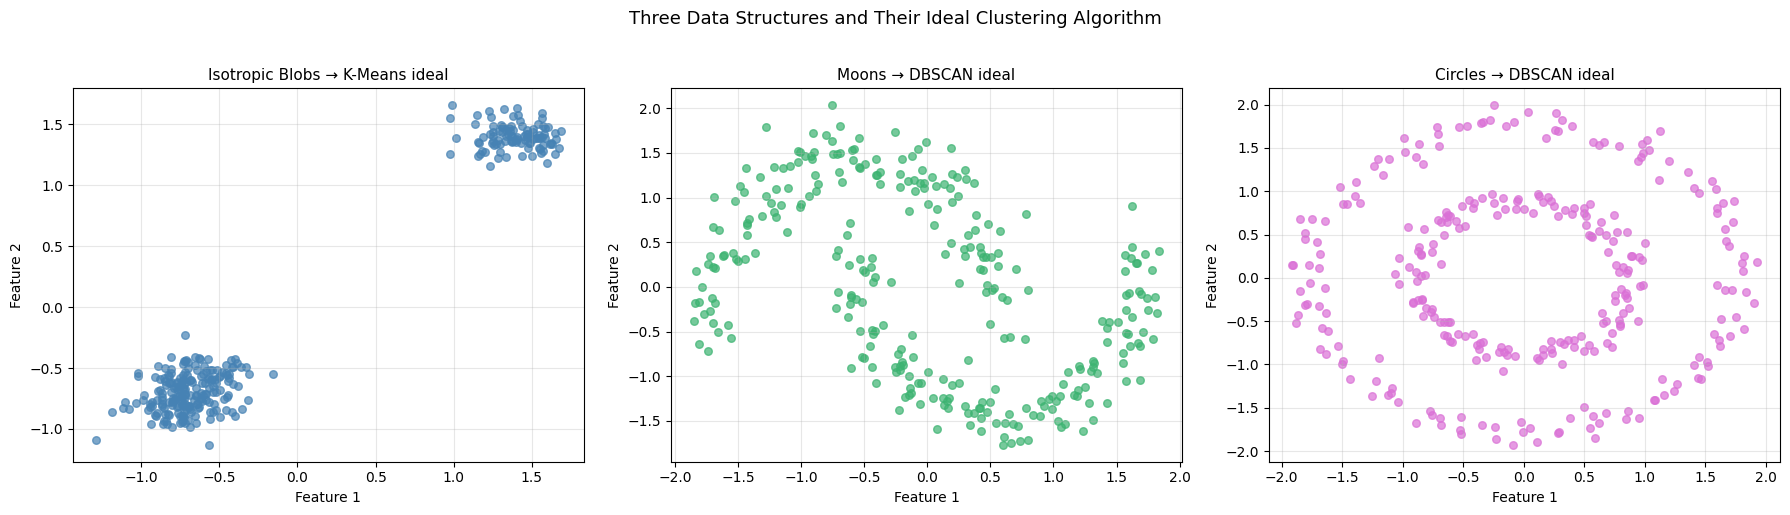

In [8]:
from sklearn.datasets import make_circles

# Three canonical datasets
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=2024)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=2024)

X_blobs   = StandardScaler().fit_transform(X_blobs)
X_moons   = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title, color in zip(
    axes,
    [X_blobs, X_moons, X_circles],
    ['Isotropic Blobs → K-Means ideal', 'Moons → DBSCAN ideal', 'Circles → DBSCAN ideal'],
    ['steelblue', 'mediumseagreen', 'orchid']
):
    ax.scatter(data[:, 0], data[:, 1], c=color, alpha=0.7, s=30)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, alpha=0.3)

plt.suptitle("Three Data Structures and Their Ideal Clustering Algorithm", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# **7. Advanced Clustering Techniques**

Beyond classical methods, scikit-learn offers more sophisticated algorithms capable of handling complex cluster shapes and probabilistic assignments.

## **7.1 Spectral Clustering**

Spectral clustering works by:
1. Constructing a **similarity graph** from the data (based on pairwise distances)
2. Computing a low-dimensional embedding of the graph using its eigenvectors (spectral decomposition)
3. Applying K-Means on the reduced representation

This makes it effective for **non-convex clusters** where Euclidean distance alone fails. It is particularly powerful for data with ring-shaped or interleaved structures.

## **7.2 Gaussian Mixture Models (GMMs)**

GMMs assume data is generated from a mixture of $K$ Gaussian distributions:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

- Each point has a **probability of belonging to each cluster** (soft assignment)
- Parameters estimated via the **Expectation-Maximization (EM)** algorithm
- Can capture **elliptical cluster shapes** and **overlapping clusters**
- `predict_proba()` returns soft membership probabilities

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


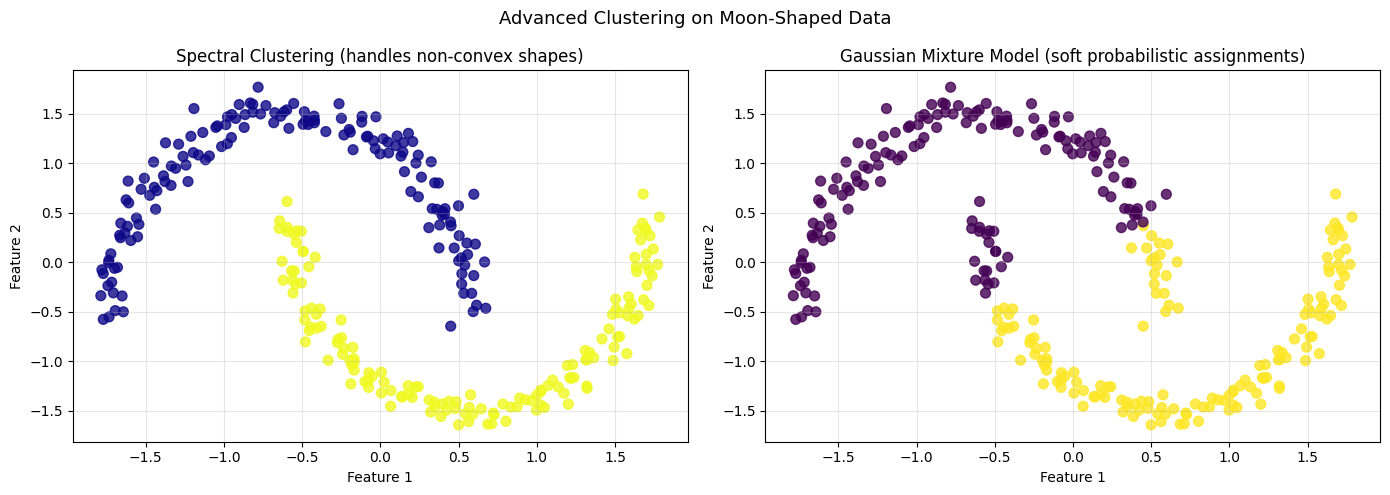


GMM soft membership (first 5 points):
   P(cluster 0)  P(cluster 1)
0        0.3780        0.6220
1        0.0474        0.9526
2        0.0005        0.9995
3        1.0000        0.0000
4        0.9999        0.0001


In [9]:
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture

# Moon dataset — challenging for K-Means
X_sc, _ = make_moons(n_samples=300, noise=0.05, random_state=2024)
X_sc = StandardScaler().fit_transform(X_sc)

# Spectral Clustering
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=2024)
y_spectral = spectral.fit_predict(X_sc)

# GMM
gmm = GaussianMixture(n_components=2, random_state=2024)
y_gmm = gmm.fit_predict(X_sc)
proba_gmm = gmm.predict_proba(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_sc[:, 0], X_sc[:, 1], c=y_spectral, cmap='plasma', s=50, alpha=0.8)
axes[0].set_title("Spectral Clustering (handles non-convex shapes)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_sc[:, 0], X_sc[:, 1], c=y_gmm, cmap='viridis', s=50, alpha=0.8)
axes[1].set_title("Gaussian Mixture Model (soft probabilistic assignments)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Advanced Clustering on Moon-Shaped Data", fontsize=13)
plt.tight_layout()
plt.show()

print("\nGMM soft membership (first 5 points):")
print(pd.DataFrame(proba_gmm[:5], columns=['P(cluster 0)', 'P(cluster 1)']).round(4).to_string())
